In [110]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import toad
from toad.transform import WOETransformer
from toad.transform import Combiner

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.metrics import RocCurveDisplay

# fetch dataset
statlog_german_credit_data = fetch_ucirepo(id=144)

# features / targets
X = statlog_german_credit_data.data.features
y = statlog_german_credit_data.data.targets

print(statlog_german_credit_data.variables)
print(statlog_german_credit_data.observations)

df = pd.concat([X, y], axis=1)
print(df)

print(df.isnull().sum())     #nu avem valori lipsa
dtypes = df.dtypes

           name     role         type     demographic  \
0    Attribute1  Feature  Categorical            None   
1    Attribute2  Feature      Integer            None   
2    Attribute3  Feature  Categorical            None   
3    Attribute4  Feature  Categorical            None   
4    Attribute5  Feature      Integer            None   
5    Attribute6  Feature  Categorical            None   
6    Attribute7  Feature  Categorical           Other   
7    Attribute8  Feature      Integer            None   
8    Attribute9  Feature  Categorical  Marital Status   
9   Attribute10  Feature  Categorical            None   
10  Attribute11  Feature      Integer            None   
11  Attribute12  Feature  Categorical            None   
12  Attribute13  Feature      Integer             Age   
13  Attribute14  Feature  Categorical            None   
14  Attribute15  Feature  Categorical           Other   
15  Attribute16  Feature      Integer            None   
16  Attribute17  Feature  Categ

In [63]:
#redenumim coloanele
atribute_redenumite = {
    'Attribute1': 'cont_curent',
    'Attribute2': 'durata_luni',
    'Attribute3': 'istoric_rambursari',
    'Attribute4': 'scop',
    'Attribute5': 'valoare_credit',
    'Attribute6': 'economii',
    'Attribute7': 'vechime_munca',
    'Attribute8': 'procent_rata_venit',
    'Attribute9': 'statut_sex',
    'Attribute10': 'alti_debitori',
    'Attribute11': 'ani_la_resedinta',
    'Attribute12': 'proprietati',
    'Attribute13': 'varsta_client',
    'Attribute14': 'rate_alte_institutii',
    'Attribute15': 'situatie_locuinta',
    'Attribute16': 'nr_credite_active_banca',
    'Attribute17': 'tip_ocupatie',
    'Attribute18': 'nr_pers_intretinere',
    'Attribute19': 'telefon',
    'Attribute20': 'alta_nationalitate',
    'class': 'clasa'  # 1 = bun, 2 = rau
}

# redenumin atribute
valori_redenumite = {
'cont_curent': {
        'A11': 'sold_mic_mediu',                              # sold_negativ
        'A12': 'sold_mic_mediu',                              # 0_200_unitm_sold_redus
        'A13': 'sold_mare',                                   # peste_200_unitm_sold_consistent
        'A14': 'fara_cont_bancar'                             # fara_cont_bancar
    },
    'istoric_rambursari': {
        'A30': 'fara_sau_istoric_bun',
        'A31': 'istoric_bun_banca_curenta',                    # toate creditele la banca curenta rambursate la timp
        'A32': 'credite_active_rambursate_corect',             # credite active ajunse la termen
        'A33': 'intarzieri_rambursare_trecut',                 # întârzieri în rambursare în trecut
        'A34': 'cont_critic_sau_alte_banci'                    # cont critic / alte credite rest (nu la această bancă)
    },
    'scop': {
        'A40': 'auto_nou',
        'A41': 'auto_folosit',
        'A42': 'mobilier_echipament',
        'A43': 'tv_radio',
        'A44': 'electrocasnice',
        'A45': 'reparatii',
        'A46': 'educatie',
        'A48': 'recalificare',
        'A49': 'afaceri',
        'A410': 'alte_scopuri'
    },
    'economii': {
         'A61': 'economii_mici',                                      # sub_100_unitm
        'A62': 'economii_mici',                                       # 100_500_unitm
        'A63': 'economii_medii',                                      # 500_1000_unitm
        'A64': 'economii_mari',                                       # peste_1000_unitm
        'A65': 'necunoscut'                                           # necunoscut (are pd similar cu econ medii)
    },
    'vechime_munca': {
        'A71': 'vechime_scazuta',                                # somer
        'A72': 'vechime_scazuta',                                # sub 1 an
        'A73': 'vechime_medie',                                  # 1–4 ani
        'A74': 'vechime_mare',                                   # 4–7 ani
        'A75': 'vechime_foarte_mare'                             # peste 7 ani
    },
    'statut_sex': {
        'A91': 'barbat',                                  # 'A91': 'm_divortat',                     # bărbat divorțat
        'A92': 'femeie',                                  # 'A92': 'f_casatorita_sau_divortata',     # femeie căsătorită/divorțată
        'A93': 'barbat',                                  # 'A93': 'm_necasatorit',                  # bărbat necăsătorit
        'A94': 'barbat',                                  # 'A94': 'm_casatorit_sau_vaduv',          # bărbat căsătorit/văduv
        'A95': 'femeie'                                   # 'A95': 'f_necasatorita',                 # femeie necăsătorită
    },
    'alti_debitori': {
        'A101': 'doar_solicitantul',
        'A102': 'cu_codebitor',
        'A103': 'cu_garant'
    },
    'proprietati': {
        'A121': 'proprietar_imobil',
        'A122': 'are_asigurari',
        'A123': 'are_bunuri_valoroase',
        'A124': 'necunoscut'
    },
    'rate_alte_institutii': {
        'A141': 'rate_alta_banca',
        'A142': 'rate_magazin',
        'A143': 'niciuna'
    },
    'situatie_locuinta': {
        'A151': 'chirie',
        'A152': 'proprie',
        'A153': 'gratis'
    },
    'tip_ocupatie': {
        'A171': 'somer_sau_strain',
        'A172': 'nespecializat',
        'A173': 'angajat',
        'A174': 'manager'
    },
    'telefon': {
        'A191': 'nu',
        'A192': 'da'
    },
    'alta_nationalitate': {
        'A201': 'da',
        'A202': 'nu'
    }
}


# Aplicăm redenumirea
df_nou = df.rename(columns=atribute_redenumite)

# Redenumim valorile
for col, mapping in valori_redenumite.items():
    if col in df_nou.columns:
        df_nou[col] = df_nou[col].map(mapping)

# Eliminăm variabilele suspecte
variabile_de_sters = [
        'proprietati',
        'situatie_locuinta',
        'alti_debitori',
      #  'vechime_munca',
      #  'tip_ocupatie',
      #  'telefon',
      #  'nr_pers_intretinere' ,
      #  'istoric_rambursari',
      #  'alta_nationalitate',
      #  'ani_la_resedinta',
      #  'nr_credite_active_banca',
      #  'rate_alte_institutii'
]

df_nou.drop(columns=[col for col in variabile_de_sters if col in df_nou.columns], inplace=True)
print(f"Următoarele coloane au fost eliminate: {variabile_de_sters}")

Următoarele coloane au fost eliminate: ['proprietati', 'situatie_locuinta', 'alti_debitori']


In [64]:
#schimbam var binara cu 0-bun 1-rau in loc de 1 si 2
df_nou['clasa'] = df_nou['clasa'].apply(lambda x: 0 if x == 1 else 1)

print(df_nou.head())
df_nou.to_csv("df_nou.csv", index=False)

        cont_curent  durata_luni                istoric_rambursari  \
0    sold_mic_mediu            6        cont_critic_sau_alte_banci   
1    sold_mic_mediu           48  credite_active_rambursate_corect   
2  fara_cont_bancar           12        cont_critic_sau_alte_banci   
3    sold_mic_mediu           42  credite_active_rambursate_corect   
4    sold_mic_mediu           24      intarzieri_rambursare_trecut   

                  scop  valoare_credit       economii        vechime_munca  \
0             tv_radio            1169     necunoscut  vechime_foarte_mare   
1             tv_radio            5951  economii_mici        vechime_medie   
2             educatie            2096  economii_mici         vechime_mare   
3  mobilier_echipament            7882  economii_mici         vechime_mare   
4             auto_nou            4870  economii_mici        vechime_medie   

   procent_rata_venit statut_sex  ani_la_resedinta  varsta_client  \
0                   4     barbat         

In [66]:
# Selectăm tipul de date
numeric_cols = df_nou.select_dtypes(include=['int64', 'float64']).drop(columns='clasa').columns.tolist()
categ_cols = df_nou.select_dtypes(include=['object']).columns.tolist()
binary_cols = df_nou.select_dtypes(include=['bool']).columns.tolist()

In [67]:
# Detectează valori extreme
detectii = toad.detect(df_nou[numeric_cols])
print(detectii.T)

               durata_luni valoare_credit procent_rata_venit ani_la_resedinta  \
type                 int64          int64              int64            int64   
size                  1000           1000               1000             1000   
missing              0.00%          0.00%              0.00%            0.00%   
unique                  33            921                  4                4   
mean_or_top1        20.903       3271.258              2.973            2.845   
std_or_top2      12.058814    2822.736876           1.118715         1.103718   
min_or_top3            4.0          250.0                1.0              1.0   
1%_or_top4             6.0         425.83                1.0              1.0   
10%_or_top5            9.0          932.0                1.0              1.0   
50%_or_bottom5        18.0         2319.5                3.0              3.0   
75%_or_bottom4        24.0        3972.25                4.0              4.0   
90%_or_bottom3        36.0  

In [68]:
print("Atribute numerice:")
for col in numeric_cols:
    print(f"- {col}")

Atribute numerice:
- durata_luni
- valoare_credit
- procent_rata_venit
- ani_la_resedinta
- varsta_client
- nr_credite_active_banca
- nr_pers_intretinere


 Variabilă: durata_luni
Min: 4
Max: 72
Mediana: 18.0
Percentile (25-75): [12. 24.]


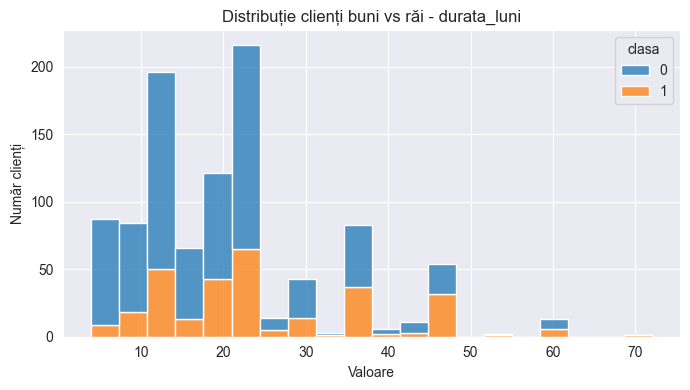

 Variabilă: valoare_credit
Min: 250
Max: 18424
Mediana: 2319.5
Percentile (25-75): [1365.5  3972.25]


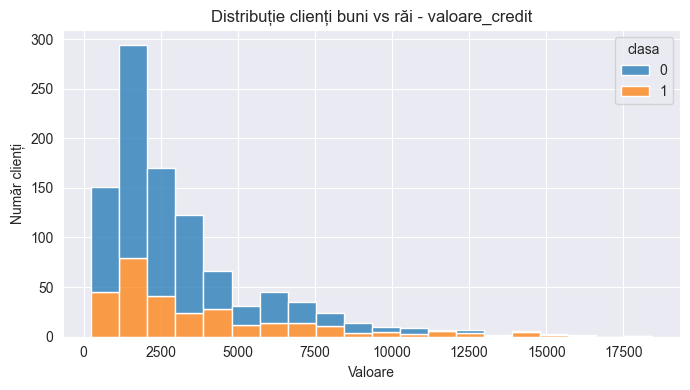

 Variabilă: procent_rata_venit
Min: 1
Max: 4
Mediana: 3.0
Percentile (25-75): [2. 4.]


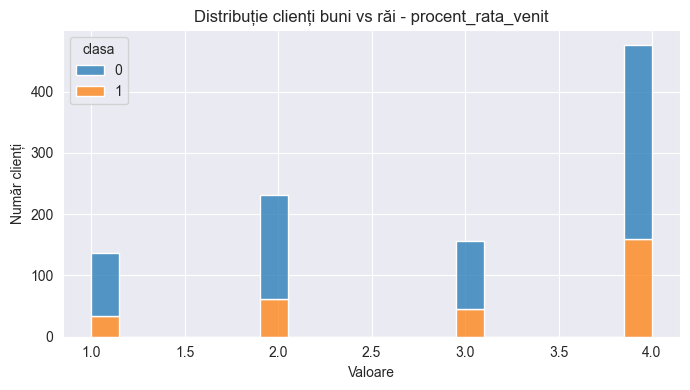

 Variabilă: ani_la_resedinta
Min: 1
Max: 4
Mediana: 3.0
Percentile (25-75): [2. 4.]


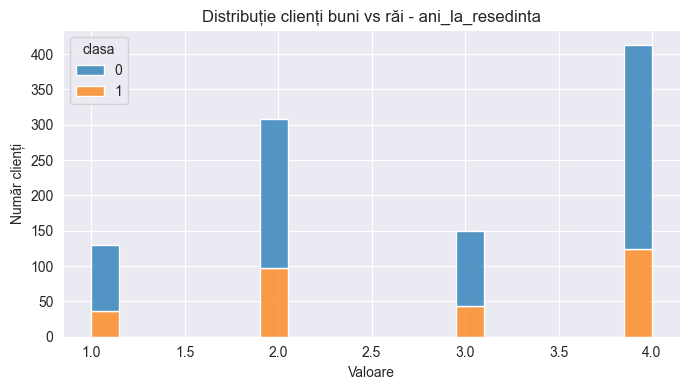

 Variabilă: varsta_client
Min: 19
Max: 75
Mediana: 33.0
Percentile (25-75): [27. 42.]


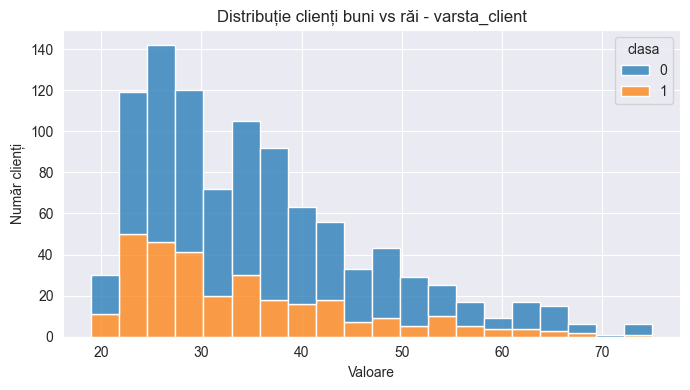

 Variabilă: nr_credite_active_banca
Min: 1
Max: 4
Mediana: 1.0
Percentile (25-75): [1. 2.]


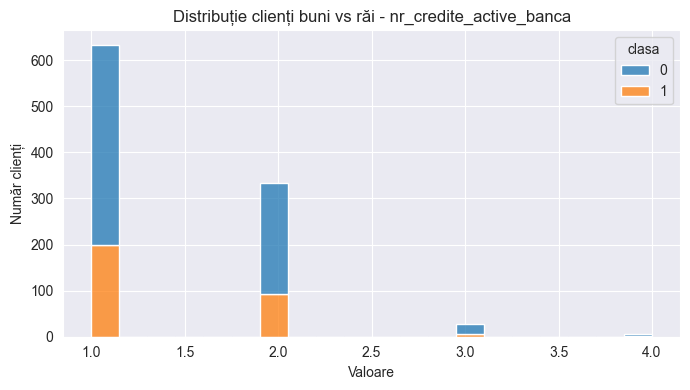

 Variabilă: nr_pers_intretinere
Min: 1
Max: 2
Mediana: 1.0
Percentile (25-75): [1. 1.]


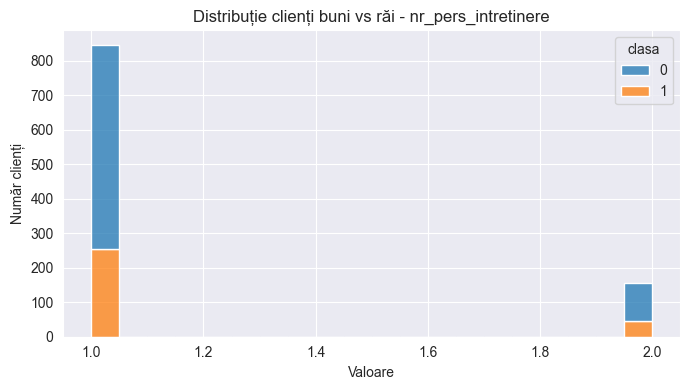

In [69]:
# Pentru fiecare coloană numerică:
for col in numeric_cols:
    print(f" Variabilă: {col}")
    print(f"Min: {df_nou[col].min()}")
    print(f"Max: {df_nou[col].max()}")
    print(f"Mediana: {df_nou[col].median()}")
    print(f"Percentile (25-75): {df_nou[col].quantile([0.25, 0.75]).values}")

    # Distribuție pe clasa țintă
    if 'clasa' in df_nou.columns:
        plt.figure(figsize=(7, 4))
        sns.histplot(data=df_nou, x=col, hue='clasa', bins=20, kde=False, multiple="stack")
        plt.title(f'Distribuție clienți buni vs răi - {col}')
        plt.xlabel('Valoare')
        plt.ylabel('Număr clienți')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

Variabilă: varsta_client
Min: 19
Max: 75
Mediana: 33.0
Percentile (25-75): [27.0, 42.0]


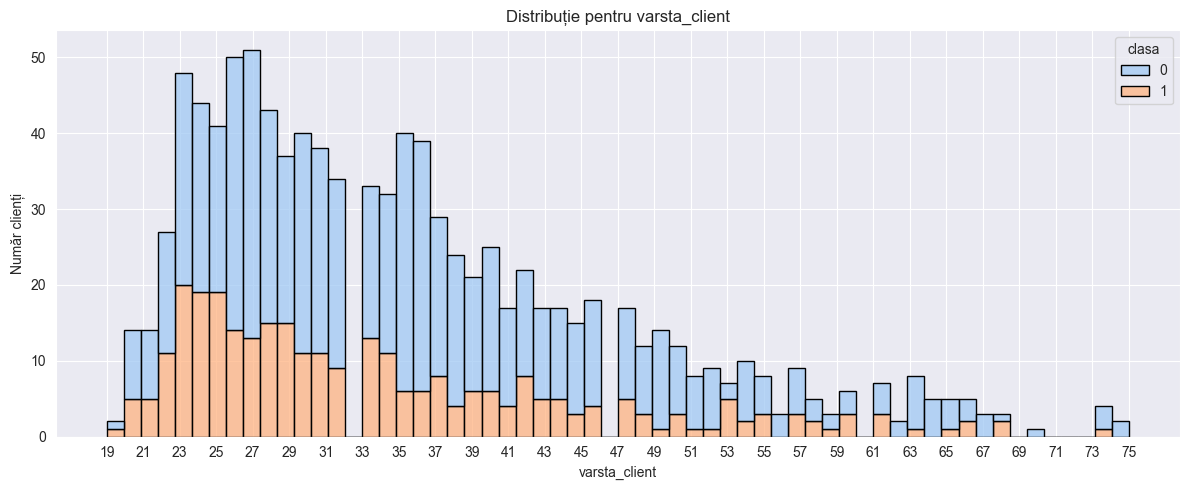

In [70]:
col = 'varsta_client'

# Calcul statistici descriptive
min_val = df_nou[col].min()
max_val = df_nou[col].max()
median_val = df_nou[col].median()
q1, q3 = df_nou[col].quantile([0.25, 0.75])

print(f"Variabilă: {col}")
print(f"Min: {min_val}")
print(f"Max: {max_val}")
print(f"Mediana: {median_val}")
print(f"Percentile (25-75): [{q1}, {q3}]")

# Histogramă detaliată
plt.figure(figsize=(12, 5))
sns.histplot(
    data=df_nou,
    x=col,
    hue='clasa',
    bins=60,  # detaliu fin
    multiple='stack',
    palette='pastel',
    edgecolor='black'
)

plt.title(f'Distribuție pentru {col}')
plt.xlabel(col)
plt.ylabel('Număr clienți')
plt.xticks(ticks=range(int(min_val), int(max_val)+1, 2))
plt.grid(True)
plt.tight_layout()
plt.show()


In [71]:
import plotly.express as px

for col in categ_cols:
    cross = df_nou.groupby([col, 'clasa']).size().reset_index(name='count')
    cross['clasa'] = cross['clasa'].map({0: 'Client bun', 1: 'Client rău'})

    # Calculăm maximul pentru axa Y
    y_max = cross['count'].max()
    y_buffer = int(y_max * 1.15)  # +15% spațiu vizual

    fig = px.bar(
        cross,
        x=col,
        y='count',
        color='clasa',
        barmode='group',
        text='count',
        color_discrete_map={
            'Client bun': '#a3c9e2',
            'Client rău': '#d9a177'
        },
        title=f'Distribuție pe clase (clienți buni vs. răi) - {col}'
    )

    fig.update_layout(
        plot_bgcolor='#1e1e1e',
        paper_bgcolor='#1e1e1e',
        font=dict(color='white'),
        legend=dict(bgcolor='#1e1e1e'),
        title_x=0.5,
        bargap=0.15
    )

    fig.update_traces(
        textposition='outside',
        marker_line_color='black',
        marker_line_width=0.5
    )

    # Actualizăm axa Y cu spațiu suplimentar
    fig.update_yaxes(range=[0, y_buffer], gridcolor='gray')

    fig.show()


In [72]:
#binning DOAR pe coloanele numerice
combiner = Combiner()
combiner.fit(df_nou[numeric_cols + ['clasa']], y='clasa', method='chi', min_samples=0.05)
df_binned_numeric = combiner.transform(df_nou[numeric_cols], labels=True)


In [73]:
# Exportăm toate regulile de binning
binning_rules = combiner.export()

# Afișăm doar pentru coloanele numerice
for col in numeric_cols:
    print(f"\n Binuri pentru variabila: {col}")
    print(binning_rules.get(col))


 Binuri pentru variabila: durata_luni
[9, 12, 13, 16, 36, 45]

 Binuri pentru variabila: valoare_credit
[3556]

 Binuri pentru variabila: procent_rata_venit
[2, 3, 4]

 Binuri pentru variabila: ani_la_resedinta
[2, 3, 4]

 Binuri pentru variabila: varsta_client
[26, 35, 37, 49]

 Binuri pentru variabila: nr_credite_active_banca
[2]

 Binuri pentru variabila: nr_pers_intretinere
[2]


In [74]:
# Construim dataframe-ul final pentru WOE: binned numerice + categorice + binare
X_final = pd.concat([
    df_binned_numeric,
    df_nou[categ_cols + binary_cols]  # fără modificări
], axis=1)
y = df_nou['clasa']

In [75]:
#vizualizam df
print(X_final.head())

     durata_luni    valoare_credit procent_rata_venit ani_la_resedinta  \
0  00.[-inf ~ 9)  00.[-inf ~ 3556)       03.[4 ~ inf)     03.[4 ~ inf)   
1  06.[45 ~ inf)   01.[3556 ~ inf)         01.[2 ~ 3)       01.[2 ~ 3)   
2   02.[12 ~ 13)  00.[-inf ~ 3556)         01.[2 ~ 3)       02.[3 ~ 4)   
3   05.[36 ~ 45)   01.[3556 ~ inf)         01.[2 ~ 3)     03.[4 ~ inf)   
4   04.[16 ~ 36)   01.[3556 ~ inf)         02.[3 ~ 4)     03.[4 ~ inf)   

    varsta_client nr_credite_active_banca nr_pers_intretinere  \
0   04.[49 ~ inf)            01.[2 ~ inf)       00.[-inf ~ 2)   
1  00.[-inf ~ 26)           00.[-inf ~ 2)       00.[-inf ~ 2)   
2   04.[49 ~ inf)           00.[-inf ~ 2)        01.[2 ~ inf)   
3    03.[37 ~ 49)           00.[-inf ~ 2)        01.[2 ~ inf)   
4   04.[49 ~ inf)            01.[2 ~ inf)        01.[2 ~ inf)   

        cont_curent                istoric_rambursari                 scop  \
0    sold_mic_mediu        cont_critic_sau_alte_banci             tv_radio   
1    sol

In [76]:
#aplicăm WOE pe toate variabilele din X_final
woe = WOETransformer()
woe.fit(X_final, y)
X_woe = woe.transform(X_final)
print(X_final.columns.tolist())


['durata_luni', 'valoare_credit', 'procent_rata_venit', 'ani_la_resedinta', 'varsta_client', 'nr_credite_active_banca', 'nr_pers_intretinere', 'cont_curent', 'istoric_rambursari', 'scop', 'economii', 'vechime_munca', 'statut_sex', 'rate_alte_institutii', 'tip_ocupatie', 'telefon', 'alta_nationalitate']


In [77]:
print(X_woe.head())

   durata_luni  valoare_credit  procent_rata_venit  ani_la_resedinta  \
0    -1.280934       -0.153492            0.157300          0.001153   
1     1.134980        0.315638           -0.155466          0.070151   
2    -0.128416       -0.153492           -0.155466         -0.054941   
3     0.524524        0.315638           -0.155466          0.001153   
4     0.108688        0.315638           -0.064539          0.001153   

   varsta_client  nr_credite_active_banca  nr_pers_intretinere  cont_curent  \
0      -0.241745                -0.134781             0.002816     0.614204   
1       0.528844                 0.074877             0.002816     0.614204   
2      -0.241745                 0.074877            -0.015409    -1.176263   
3      -0.195120                 0.074877            -0.015409     0.614204   
4      -0.241745                -0.134781            -0.015409     0.614204   

   istoric_rambursari      scop  economii  vechime_munca  statut_sex  \
0           -0.73374

In [78]:
from toad.transform import WOETransformer
import pandas as pd

woe = WOETransformer()
woe.fit(X_final, y)

variabile_selectate = ['durata_luni', 'varsta_client', 'cont_curent', 'scop']

# Exportă dicționarul de WOE-uri
woe_dict = woe.export()

tabele = []
for var in variabile_selectate:
    if var in woe_dict:
        for bin_val, woe_val in woe_dict[var].items():
            tabele.append({
                'Variabilă': var,
                'Bin / Categorie': str(bin_val),
                'WOE': round(woe_val, 4)
            })

# Convertim în DataFrame și afișăm
df_woe_bins = pd.DataFrame(tabele)
print(df_woe_bins)


        Variabilă      Bin / Categorie     WOE
0     durata_luni        00.[-inf ~ 9) -1.2809
1     durata_luni          01.[9 ~ 12) -0.5536
2     durata_luni         02.[12 ~ 13) -0.1284
3     durata_luni         03.[13 ~ 16) -0.6653
4     durata_luni         04.[16 ~ 36)  0.1087
5     durata_luni         05.[36 ~ 45)  0.5245
6     durata_luni        06.[45 ~ inf)  1.1350
7   varsta_client       00.[-inf ~ 26)  0.5288
8   varsta_client         01.[26 ~ 35)  0.0605
9   varsta_client         02.[35 ~ 37) -0.8725
10  varsta_client         03.[37 ~ 49) -0.1951
11  varsta_client        04.[49 ~ inf) -0.2417
12    cont_curent     fara_cont_bancar -1.1763
13    cont_curent            sold_mare -0.4055
14    cont_curent       sold_mic_mediu  0.6142
15           scop              afaceri  0.2305
16           scop         alte_scopuri  0.5108
17           scop         auto_folosit -0.7738
18           scop             auto_nou  0.3592
19           scop             educatie  0.6061
20           

In [79]:
#concat totul într-un singur dataframe final pt VIZUALIZARE BIN +WOE df_final
df_final = pd.concat([X_final.add_suffix('_binned'), X_woe.add_suffix('_woe'), y], axis=1)



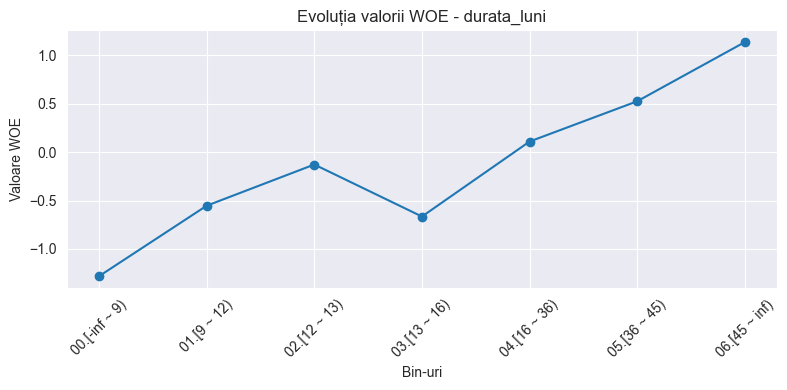

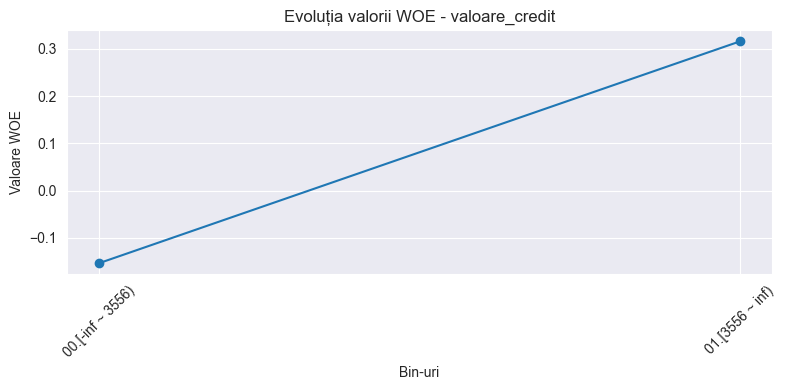

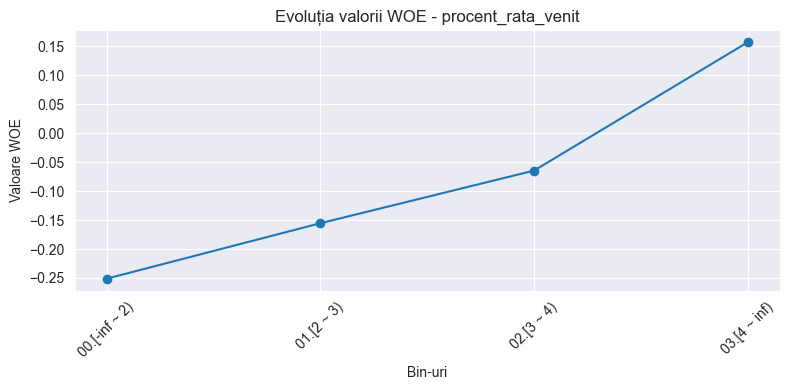

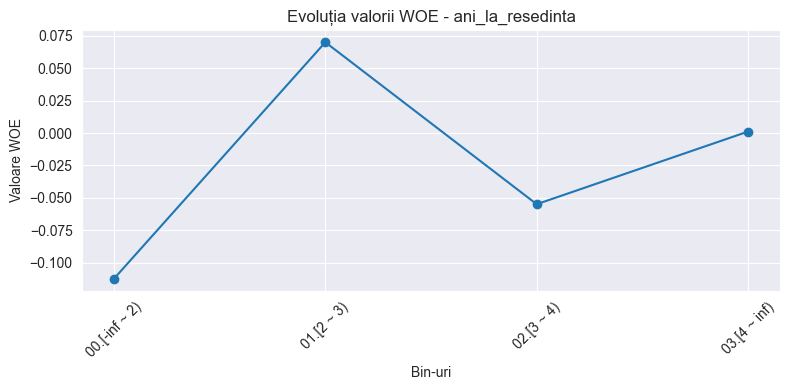

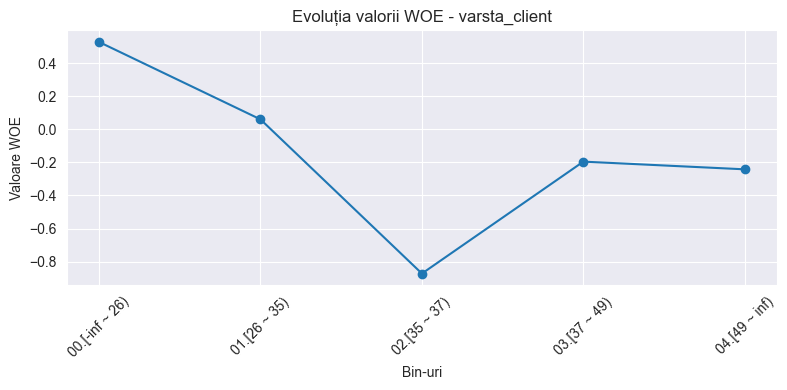

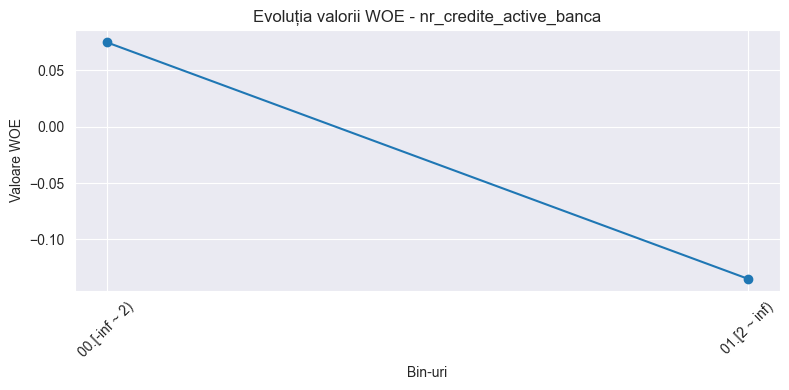

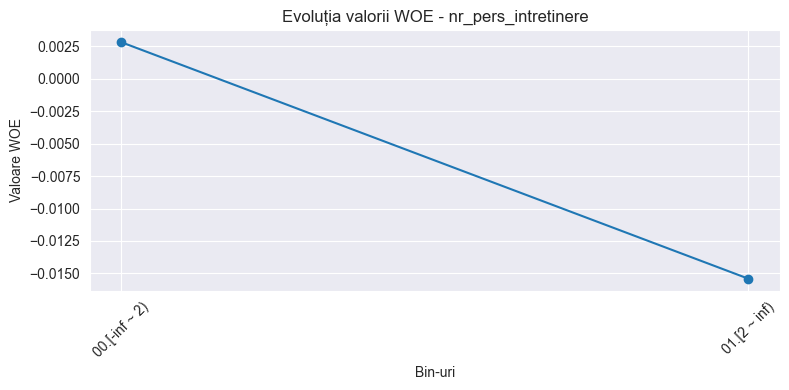

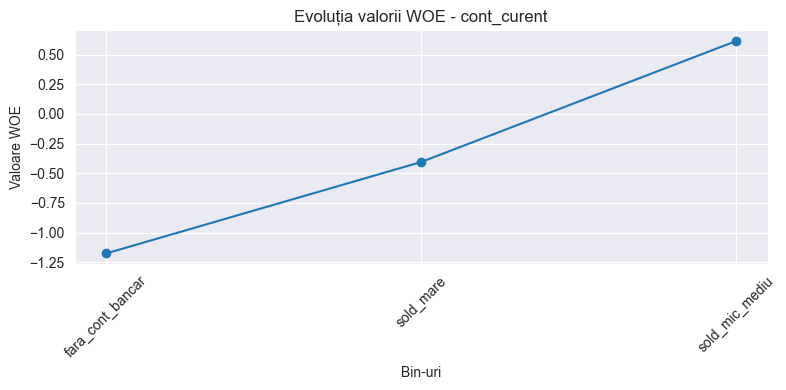

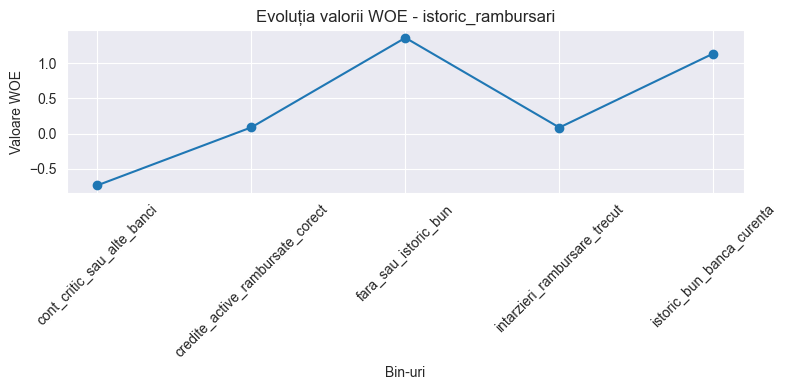

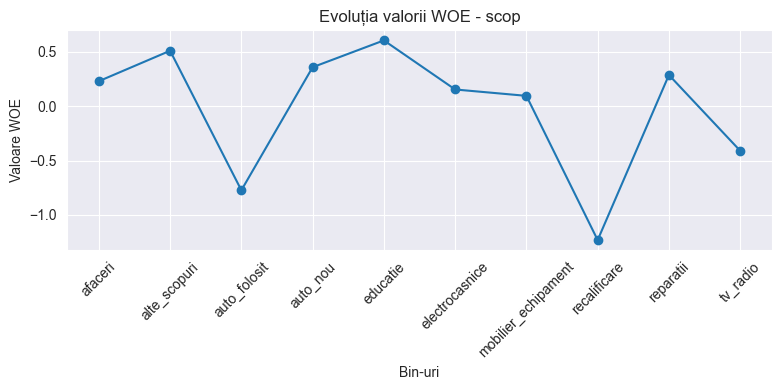

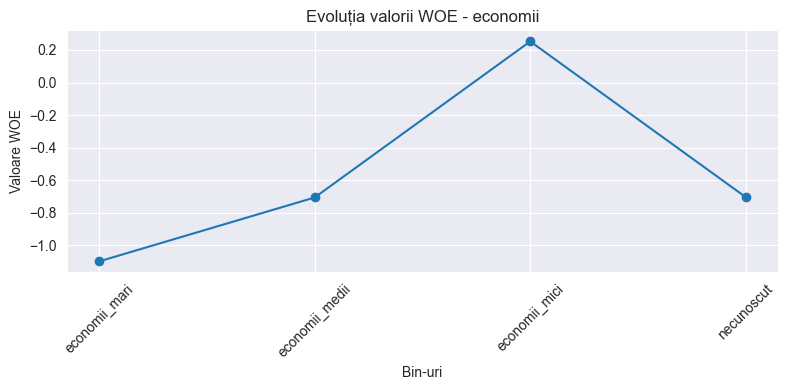

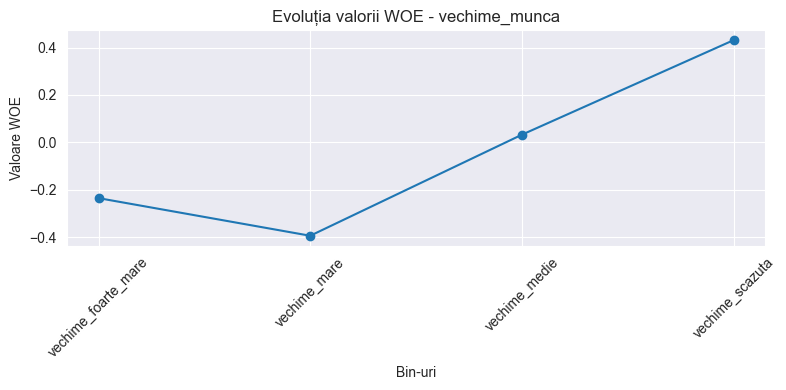

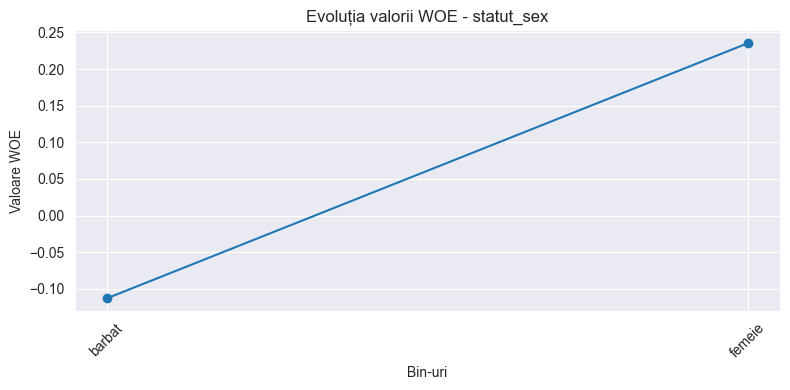

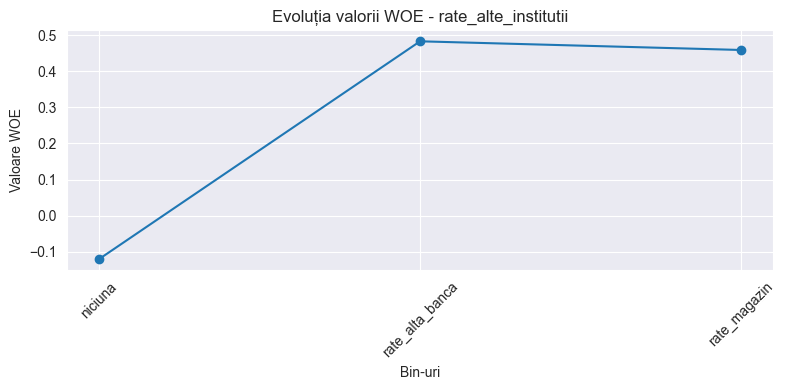

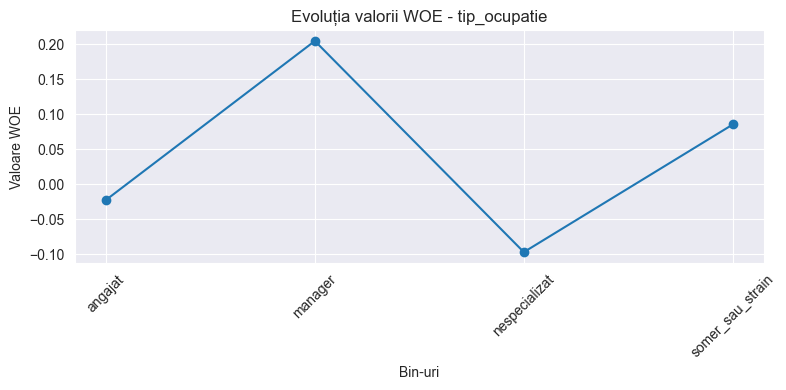

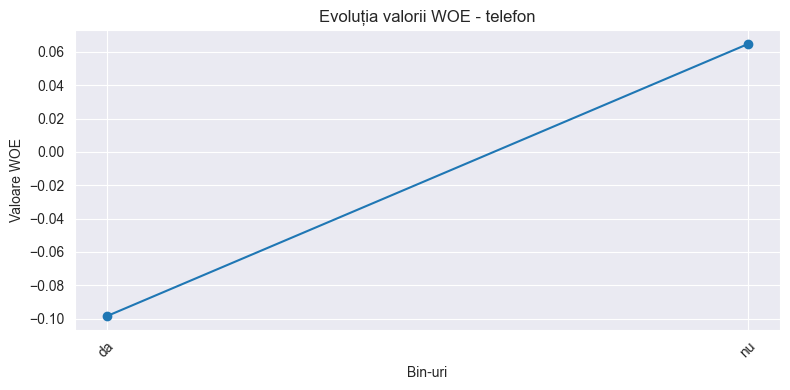

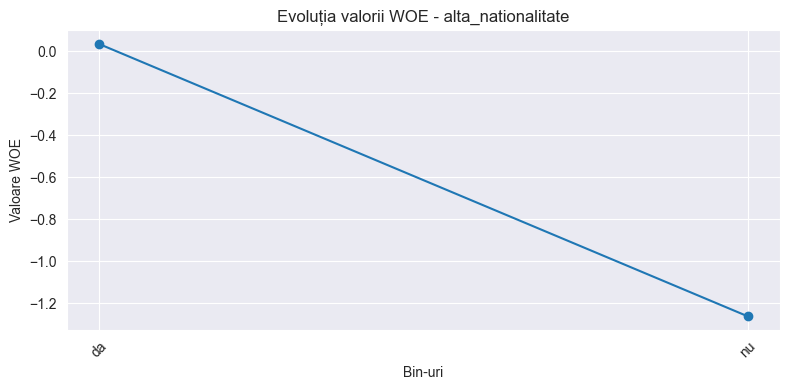

In [80]:
import matplotlib.pyplot as plt

# Selectăm toate variabilele care au atât _binned cât și _woe
binned_vars = [col.replace('_binned', '') for col in df_final.columns if col.endswith('_binned')]

for var in binned_vars:
    try:
        col_bin = f"{var}_binned"
        col_woe = f"{var}_woe"

        df_plot = df_final[[col_bin, col_woe]].drop_duplicates().sort_values(by=col_bin)
        df_plot.columns = ['Bin', 'WOE']

        plt.figure(figsize=(8, 4))
        plt.plot(df_plot['Bin'], df_plot['WOE'], marker='o', linestyle='-')
        plt.title(f'Evoluția valorii WOE - {var}')
        plt.xlabel('Bin-uri')
        plt.ylabel('Valoare WOE')
        plt.xticks(rotation=45)
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Eroare la variabila {var}: {e}")


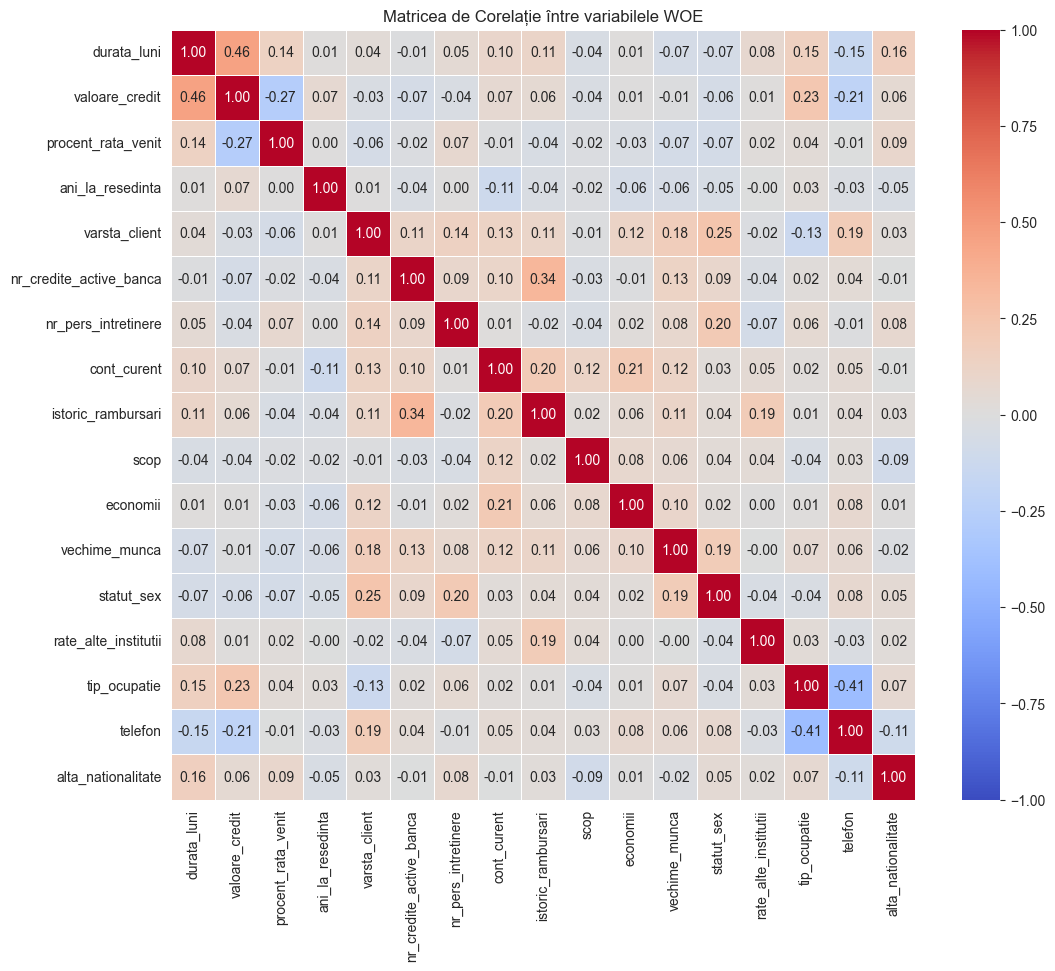

In [81]:
#Verificăm corelații pe datele WOE
cor_matrix = X_woe.corr()

#Vizualizare
plt.figure(figsize=(12, 10))
sns.heatmap(cor_matrix,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            vmin=-1, vmax=1,
            linewidths=0.5)

plt.title("Matricea de Corelație între variabilele WOE")
plt.show()

In [82]:
#IV complet pentru toate variabilele (cu binned aplicat) + AFISARE
iv_table = toad.quality(X_final.assign(clasa=y), target='clasa', iv_only=False).sort_values(by='iv', ascending=False)

# interpretarea IV în funcție de intervale
def interpret_iv(iv):
    if iv < 0.02:
        return 'foarte slabă'
    elif iv < 0.1:
        return 'slabă'
    elif iv < 0.3:
        return 'moderată'
    else:
        return 'puternică'

iv_table['interpretare_iv'] = iv_table['iv'].apply(interpret_iv)

#afișare IV
print("\nTabel IV:")
print(iv_table[['iv','interpretare_iv', 'gini', 'entropy', 'unique' ]])




Tabel IV:
                               iv interpretare_iv      gini   entropy  unique
cont_curent              0.639372       puternică  0.370882  0.548086     3.0
durata_luni              0.301807       puternică  0.395222  0.580614     7.0
istoric_rambursari       0.293234        moderată  0.394090  0.580631     5.0
economii                 0.194426        moderată  0.404994  0.591548     4.0
scop                     0.169195        moderată  0.405990  0.593609    10.0
varsta_client            0.124116        moderată  0.409478  0.598121     5.0
vechime_munca            0.085301           slabă  0.412404  0.601906     4.0
rate_alte_institutii     0.057615           slabă  0.414608  0.604713     3.0
valoare_credit           0.048253           slabă  0.415622  0.605757     2.0
alta_nationalitate       0.043877           slabă  0.417170  0.606828     2.0
statut_sex               0.026543           slabă  0.417606  0.608059     2.0
procent_rata_venit       0.026322           slabă  0.

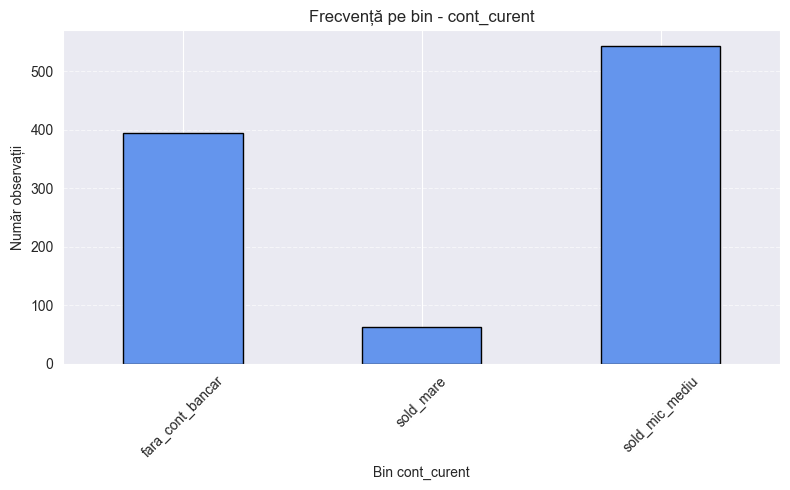

     Bin cont_curent       WOE
0     sold_mic_mediu  0.614204
2   fara_cont_bancar -1.176263
27         sold_mare -0.405465


In [83]:
# woe distrib pt cont_curent
df_final['cont_curent_binned'].value_counts().sort_index().plot(
    kind='bar', figsize=(8, 5), color='cornflowerblue', edgecolor='black', title='Frecvență pe bin - cont_curent'
)
plt.xlabel("Bin cont_curent")
plt.ylabel("Număr observații")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

woe_cont_curent = df_final[['cont_curent_binned', 'cont_curent_woe']].drop_duplicates()
woe_cont_curent.columns = ['Bin cont_curent', 'WOE']
print(woe_cont_curent)

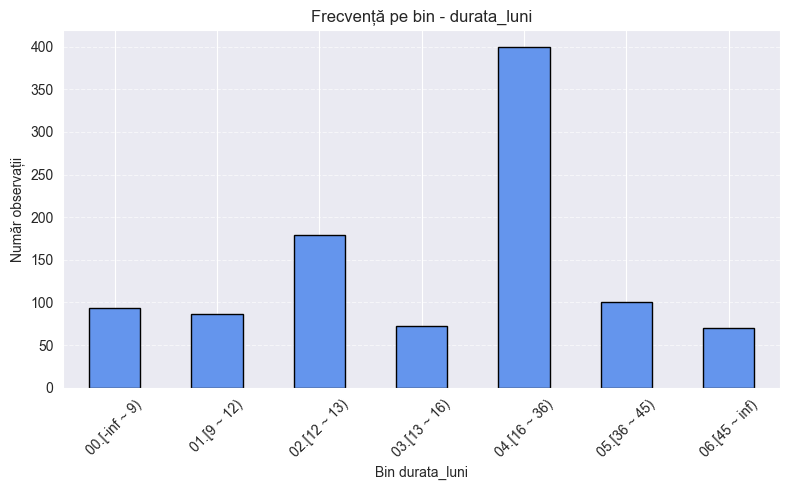

   Bin durata_luni       WOE
0    00.[-inf ~ 9) -1.280934
1    06.[45 ~ inf)  1.134980
2     02.[12 ~ 13) -0.128416
3     05.[36 ~ 45)  0.524524
4     04.[16 ~ 36)  0.108688
14    03.[13 ~ 16) -0.665290
20     01.[9 ~ 12) -0.553595


In [84]:
# binurile variabilei durata_luni
df_final['durata_luni_binned'].value_counts().sort_index().plot(
    kind='bar', figsize=(8, 5), color='cornflowerblue', edgecolor='black', title='Frecvență pe bin - durata_luni'
)
plt.xlabel("Bin durata_luni")
plt.ylabel("Număr observații")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Tabel cu valorile WOE pentru fiecare bin din durata_luni
woe_durata_luni = df_final[['durata_luni_binned', 'durata_luni_woe']].drop_duplicates()
woe_durata_luni.columns = ['Bin durata_luni', 'WOE']
print(woe_durata_luni)

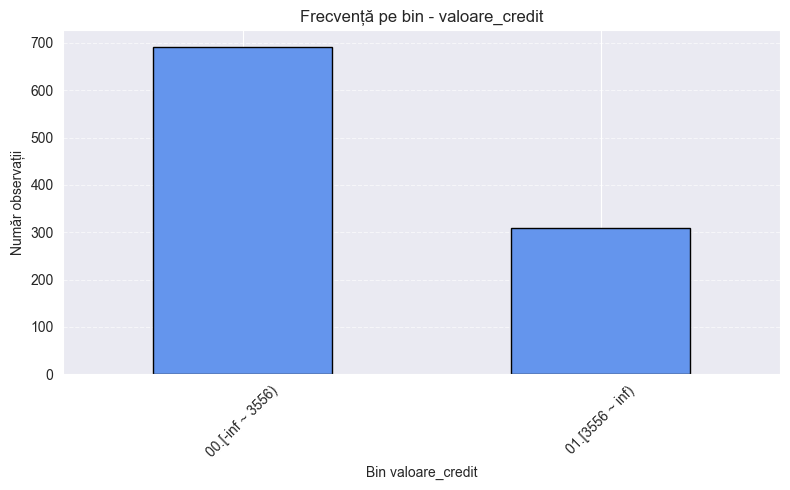

  Bin valoare_credit       WOE
0   00.[-inf ~ 3556) -0.153492
1    01.[3556 ~ inf)  0.315638


In [85]:
# binurile variabilei valoare_credit
df_final['valoare_credit_binned'].value_counts().sort_index().plot(
    kind='bar', figsize=(8, 5), color='cornflowerblue', edgecolor='black', title='Frecvență pe bin - valoare_credit'
)
plt.xlabel("Bin valoare_credit")
plt.ylabel("Număr observații")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# WOE pentru fiecare bin din valoare_credit
woe_valoare_credit = df_final[['valoare_credit_binned', 'valoare_credit_woe']].drop_duplicates()
woe_valoare_credit.columns = ['Bin valoare_credit', 'WOE']
print(woe_valoare_credit)

In [86]:
#verificam iar monotonie cu PD + distributie
binned_columns = [col for col in df_final.columns if col.endswith('_binned')]

for col in binned_columns:
    print(f"\nStatistici pe {col}:")
    stat = df_final.groupby(col)['clasa'].agg(['count', 'mean']).reset_index()
    stat.rename(columns={'mean': 'PD', 'count': 'Numar clienti'}, inplace=True)
    display(stat)


Statistici pe durata_luni_binned:


,durata_luni_binned,Numar clienti,PD
0,00.[-inf ~ 9),94,0.106383
1,01.[9 ~ 12),86,0.197674
2,02.[12 ~ 13),179,0.273743
3,03.[13 ~ 16),72,0.180556
4,04.[16 ~ 36),399,0.323308
5,05.[36 ~ 45),100,0.420000
6,06.[45 ~ inf),70,0.571429



Statistici pe valoare_credit_binned:


,valoare_credit_binned,Numar clienti,PD
0,00.[-inf ~ 3556),692,0.268786
1,01.[3556 ~ inf),308,0.370130



Statistici pe procent_rata_venit_binned:


...

,tip_ocupatie_binned,Numar clienti,PD
0,angajat,630,0.295238
1,manager,148,0.344595
2,nespecializat,200,0.280000
3,somer_sau_strain,22,0.318182



Statistici pe telefon_binned:


,telefon_binned,Numar clienti,PD
0,da,404,0.279703
1,nu,596,0.313758



Statistici pe alta_nationalitate_binned:


,alta_nationalitate_binned,Numar clienti,PD
0,da,963,0.307373
1,nu,37,0.108108


In [87]:
#woe + goods + bads / bins pt vizualizare
woe_table = []

for col in X_final.columns:
    grup = df_nou[['clasa']].join(X_final[col])
    stats = grup.groupby(col)['clasa'].agg(['count', 'sum']).rename(
        columns={'count': 'total', 'sum': 'bads'}
    )
    stats['goods'] = stats['total'] - stats['bads']
    stats['variable'] = col
    stats['bin'] = stats.index
    stats['woe'] = stats['bin'].map(woe.export().get(col, {}))
    woe_table.append(stats.reset_index(drop=True))

# Concatenăm totul într-un singur DataFrame
woe_table_df = pd.concat(woe_table, ignore_index=True)

# Rearanjăm coloanele
woe_table_df = woe_table_df[['variable', 'bin', 'goods', 'bads', 'woe']]
print(woe_table_df)

              variable               bin  goods  bads       woe
0          durata_luni     00.[-inf ~ 9)     84    10 -1.280934
1          durata_luni       01.[9 ~ 12)     69    17 -0.553595
2          durata_luni      02.[12 ~ 13)    130    49 -0.128416
3          durata_luni      03.[13 ~ 16)     59    13 -0.665290
4          durata_luni      04.[16 ~ 36)    270   129  0.108688
..                 ...               ...    ...   ...       ...
60        tip_ocupatie  somer_sau_strain     15     7  0.085158
61             telefon                da    291   113 -0.098638
62             telefon                nu    409   187  0.064691
63  alta_nationalitate                da    667   296  0.034867
64  alta_nationalitate                nu     33     4 -1.262915

[65 rows x 5 columns]


In [88]:
#VAR1

# regresie logistica cu toate variabilele
# Split train-test
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(
    X_woe, y, test_size=0.3, stratify=y, random_state=42
)

# Antrenare model
model_70 = LogisticRegression(max_iter=1000)
model_70.fit(X_train_70, y_train_70)

# Predictii
y_pred_70 = model_70.predict(X_test_70)
y_prob_70 = model_70.predict_proba(X_test_70)[:, 1]

# Evaluare
print("\nClasificare VAR1 - toate variabilele (70-30):")
print(classification_report(y_test_70, y_pred_70))
print("AUC:", roc_auc_score(y_test_70, y_prob_70))
print("Confusion Matrix:\n", confusion_matrix(y_test_70, y_pred_70))


Clasificare VAR1 - toate variabilele (70-30):
              precision    recall  f1-score   support

           0       0.82      0.91      0.86       210
           1       0.72      0.52      0.61        90

    accuracy                           0.80       300
   macro avg       0.77      0.72      0.73       300
weighted avg       0.79      0.80      0.79       300

AUC: 0.8178306878306879
Confusion Matrix:
 [[192  18]
 [ 43  47]]


In [89]:
#Var2

# regresie logistica eliminam var foarte slabe IV <= 0.02
variabile_utilizate = iv_table[iv_table['iv'] >= 0.02].index.tolist()
X_iv_70  = X_woe[variabile_utilizate]

# Split train-test
X_train_iv_70, X_test_iv_70, y_train_iv_70, y_test_iv_70 = train_test_split(
    X_iv_70, y, test_size=0.3, stratify=y, random_state=42 )

# Antrenare model
model_iv_70 = LogisticRegression(max_iter=1000)
model_iv_70.fit(X_train_iv_70, y_train_iv_70)

# Predictii
y_pred_iv_70 = model_iv_70.predict(X_test_iv_70)
y_prob_iv_70 = model_iv_70.predict_proba(X_test_iv_70)[:, 1]

# Evaluare
print("\nClasificare VAR2 - fără variabile foarte slabe (70-30):")
print(classification_report(y_test_iv_70, y_pred_iv_70))
print("AUC:", roc_auc_score(y_test_iv_70, y_prob_iv_70))
print("Confusion Matrix:\n", confusion_matrix(y_test_iv_70, y_pred_iv_70))


Clasificare VAR2 - fără variabile foarte slabe (70-30):
              precision    recall  f1-score   support

           0       0.81      0.91      0.86       210
           1       0.72      0.51      0.60        90

    accuracy                           0.79       300
   macro avg       0.77      0.71      0.73       300
weighted avg       0.79      0.79      0.78       300

AUC: 0.8162433862433864
Confusion Matrix:
 [[192  18]
 [ 44  46]]


In [90]:
#Var 3

#toate var 80-20
# Split train-test
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(
    X_woe, y, test_size=0.2, stratify=y, random_state=42
)

# Antrenare model
model_80 = LogisticRegression(max_iter=1000)
model_80.fit(X_train_80, y_train_80)

# Predictii
y_pred_80 = model_80.predict(X_test_80)
y_prob_80 = model_80.predict_proba(X_test_80)[:, 1]

# Evaluare
print("\n Clasificare VAR3 - toate variabilele (80-20):")
print(classification_report(y_test_80, y_pred_80))
print("AUC:", roc_auc_score(y_test_80, y_prob_80))
print("Confusion Matrix:\n", confusion_matrix(y_test_80, y_pred_80))



 Clasificare VAR3 - toate variabilele (80-20):
              precision    recall  f1-score   support

           0       0.82      0.91      0.86       140
           1       0.72      0.55      0.62        60

    accuracy                           0.80       200
   macro avg       0.77      0.73      0.74       200
weighted avg       0.79      0.80      0.79       200

AUC: 0.8220238095238095
Confusion Matrix:
 [[127  13]
 [ 27  33]]


In [91]:
#var 4

#fara var foarte slabe 80-20
variabile_utilizate = iv_table[iv_table['iv'] >= 0.02].index.tolist()
X_model_iv_80 = X_woe[variabile_utilizate]

# Split train-test
X_train_iv_80, X_test_iv_80, y_train_iv_80, y_test_iv_80 = train_test_split(
    X_model_iv_80, y, test_size=0.2, stratify=y, random_state=42
)

# Antrenare model
model_iv_80 = LogisticRegression(max_iter=1000)
model_iv_80.fit(X_train_iv_80, y_train_iv_80)

# Predictii
y_pred_iv_80 = model_iv_80.predict(X_test_iv_80)
y_prob_iv_80 = model_iv_80.predict_proba(X_test_iv_80)[:, 1]

# Evaluare
print("\nClasificare VAR4 -  fără variabile foarte slabe (80-20):")
print(classification_report(y_test_iv_80, y_pred_iv_80))
print("AUC:", roc_auc_score(y_test_iv_80, y_prob_iv_80))
print("Confusion Matrix:\n", confusion_matrix(y_test_iv_80, y_pred_iv_80))


Clasificare VAR4 -  fără variabile foarte slabe (80-20):
              precision    recall  f1-score   support

           0       0.82      0.91      0.86       140
           1       0.72      0.55      0.62        60

    accuracy                           0.80       200
   macro avg       0.77      0.73      0.74       200
weighted avg       0.79      0.80      0.79       200

AUC: 0.8189285714285715
Confusion Matrix:
 [[127  13]
 [ 27  33]]


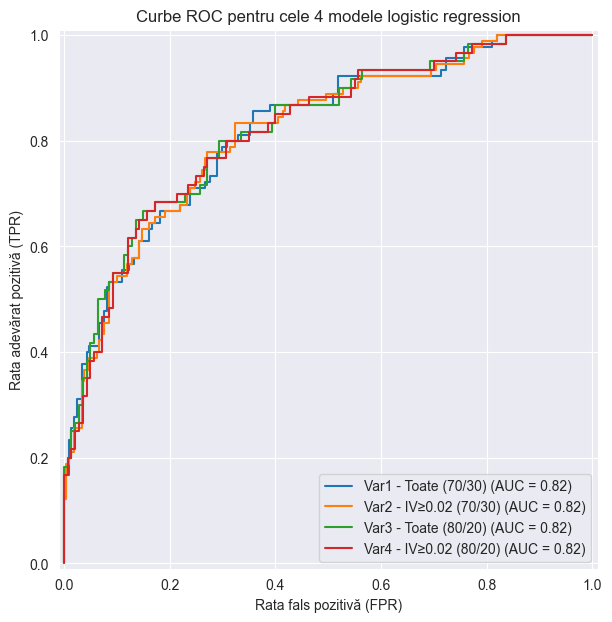

In [92]:
# Vizualizare curbe roc
# Inițializăm figura
plt.figure(figsize=(10, 7))

# ROC pentru VAR1 - toate variabilele, split 70-30
RocCurveDisplay.from_predictions(y_test_70, y_prob_70, name="Var1 - Toate (70/30)", ax=plt.gca())

# ROC pentru VAR2 - fără variabile foarte slabe, split 70-30
RocCurveDisplay.from_predictions(y_test_iv_70, y_prob_iv_70, name="Var2 - IV≥0.02 (70/30)", ax=plt.gca())

# ROC pentru VAR3 - toate variabilele, split 80-20
RocCurveDisplay.from_predictions(y_test_80, y_prob_80, name="Var3 - Toate (80/20)", ax=plt.gca())

# ROC pentru VAR4 - fără variabile foarte slabe, split 80-20
RocCurveDisplay.from_predictions(y_test_iv_80, y_prob_iv_80, name="Var4 - IV≥0.02 (80/20)", ax=plt.gca())

plt.title("Curbe ROC pentru cele 4 modele logistic regression")
plt.xlabel("Rata fals pozitivă (FPR)")
plt.ylabel("Rata adevărat pozitivă (TPR)")
plt.grid(True)
plt.legend(loc="lower right")
plt.show()

In [93]:
#psi train test
def calcul_psi(train_df, test_df):
    psi_values = {}

    for col in train_df.columns:
        train_dist = train_df[col].value_counts(normalize=True)
        test_dist = test_df[col].value_counts(normalize=True)

        bins = set(train_dist.index).union(set(test_dist.index))
        psi = 0

        for b in bins:
            p = train_dist.get(b, 0.0001)  # proporția în train
            q = test_dist.get(b, 0.0001)   # proporția în test
            psi += (p - q) * np.log(p / q)

        psi_values[col] = round(psi, 4)

    return pd.DataFrame(list(psi_values.items()), columns=["Variabilă", "PSI"])



In [94]:
# refacem split-ul pt VAR3
X_train_binned_var3, X_test_binned_var3, _, _ = train_test_split(
    X_final, y, test_size=0.2, stratify=y, random_state=42
)

# aplicăm PSI
psi_df_var3 = calcul_psi(X_train_binned_var3, X_test_binned_var3)
print(psi_df_var3.sort_values(by="PSI", ascending=False))


                  Variabilă     PSI
9                      scop  0.0727
4             varsta_client  0.0473
0               durata_luni  0.0337
2        procent_rata_venit  0.0241
3          ani_la_resedinta  0.0146
8        istoric_rambursari  0.0138
14             tip_ocupatie  0.0109
10                 economii  0.0075
6       nr_pers_intretinere  0.0050
11            vechime_munca  0.0037
5   nr_credite_active_banca  0.0033
16       alta_nationalitate  0.0023
1            valoare_credit  0.0021
13     rate_alte_institutii  0.0021
15                  telefon  0.0005
7               cont_curent  0.0004
12               statut_sex  0.0002


In [ ]:
#scor

In [95]:
p_bad = y_train_80.mean()
odds_ref = (1 - p_bad) / p_bad

print(f"Proporția clienților neplatnici (p_bad): {p_bad:.4f}")
print(f"Șansele de referință (odds_ref): {odds_ref:.2f}")

Proporția clienților neplatnici (p_bad): 0.3000
Șansele de referință (odds_ref): 2.33


In [96]:
PDO = 20
score_ref = 600

#Probabilități din setul de testare
y_prob_80 = model_80.predict_proba(X_test_80)[:, 1]

#Log-odds:
log_odds_80 = np.log(y_prob_80 / (1 - y_prob_80))

#Factor și Offset
factor = PDO / np.log(2)
offset = score_ref + factor * np.log(odds_ref)

#Scor final
score_80 = offset - factor * log_odds_80

In [ ]:
#scorecard

In [97]:
scorecard = []
woe_dict = woe.export()
coefficients = dict(zip(X_woe.columns, model_80.coef_[0]))

for var in X_final.columns:
    if var in coefficients:
        beta = coefficients[var]
        for bin_val, woe_val in woe_dict.get(var, {}).items():
            scor_bin = -woe_val * beta * factor
            scorecard.append({
                'Variabilă': var,
                'Atribut': bin_val,
                'Punctaj': round(scor_bin, 2)
            })

# Dicționar care mapează fiecare variabilă la poziția ei originală
ordine_variabile = {var: i for i, var in enumerate(X_final.columns)}

scorecard_df = pd.DataFrame(scorecard)
scorecard_df['Ordine'] = scorecard_df['Variabilă'].map(ordine_variabile)

# Sortare
scorecard_df = scorecard_df.sort_values(by=['Ordine', 'Punctaj'], ascending=[True, True]).drop(columns='Ordine').reset_index(drop=True)


print(scorecard_df.head(20))


             Variabilă           Atribut  Punctaj
0          durata_luni     06.[45 ~ inf)   -30.75
1          durata_luni      05.[36 ~ 45)   -14.21
2          durata_luni      04.[16 ~ 36)    -2.94
3          durata_luni      02.[12 ~ 13)     3.48
4          durata_luni       01.[9 ~ 12)    15.00
5          durata_luni      03.[13 ~ 16)    18.02
6          durata_luni     00.[-inf ~ 9)    34.70
7       valoare_credit   01.[3556 ~ inf)    -0.50
8       valoare_credit  00.[-inf ~ 3556)     0.25
9   procent_rata_venit      03.[4 ~ inf)    -5.43
10  procent_rata_venit        02.[3 ~ 4)     2.23
11  procent_rata_venit        01.[2 ~ 3)     5.36
12  procent_rata_venit     00.[-inf ~ 2)     8.67
13    ani_la_resedinta        01.[2 ~ 3)    -1.13
14    ani_la_resedinta      03.[4 ~ inf)    -0.02
15    ani_la_resedinta        02.[3 ~ 4)     0.89
16    ani_la_resedinta     00.[-inf ~ 2)     1.82
17       varsta_client    00.[-inf ~ 26)    -7.37
18       varsta_client      01.[26 ~ 35)    -0.84


In [98]:
scorecard_df.to_csv("scorecard.csv")

In [99]:
#df cu toate score urile
df_score_var3 = pd.DataFrame({
    'scor_final': score_80,
    'log_odds': log_odds_80,
    'clasa_reala': y_test_80.reset_index(drop=True)
})

df_score_var3.head()

,scor_final,log_odds,clasa_reala
0,651.165032,-0.925947,0
1,652.723120,-0.979946,0
2,615.463489,0.311374,1
3,601.225926,0.804810,0
4,661.861055,-1.296643,1


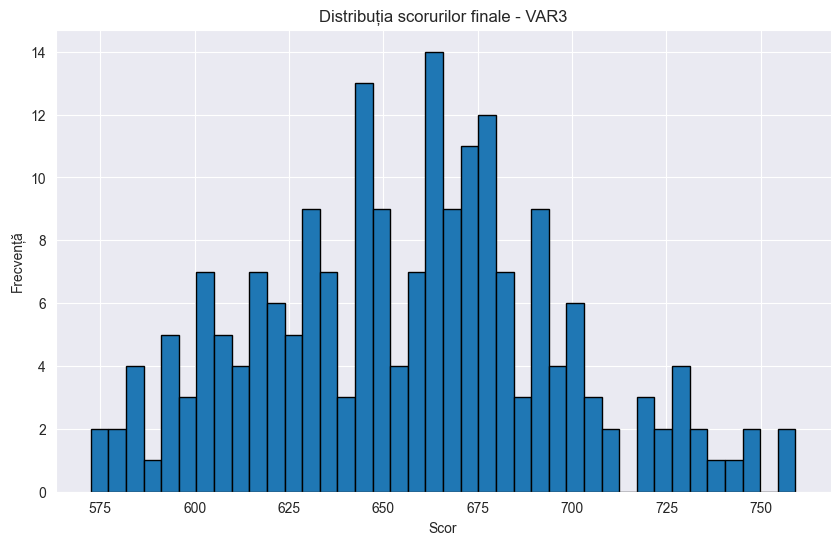

In [100]:
#vizualizare distributie scor
plt.figure(figsize=(10, 6))
plt.hist(df_score_var3['scor_final'], bins=40, edgecolor='black')
plt.title("Distribuția scorurilor finale - VAR3")
plt.xlabel("Scor")
plt.ylabel("Frecvență")
plt.grid(True)
plt.show()

In [101]:
#SCORE RATINGS
rating = ['D', 'C', 'CC' , 'B', 'BB', 'A', 'AA']
rating2= ['AA', 'A', 'BB', 'B', 'CC', 'C' , 'D']

#impartim scoreurile finale in 6 benzi de rating egale
df_score_var3['rating'] = pd.qcut(df_score_var3['scor_final'], q=7, labels=rating)

In [109]:
#pd pe rating
def calculeaza_pd_pe_rating(df, rating_col='rating', target_col='clasa_reala'):
    tabel = df.groupby(rating_col, observed=True)[target_col].agg(
        total_clienti='count',
        nr_rai='sum'
    ).reset_index()

    tabel['nr_buni'] = tabel['total_clienti'] - tabel['nr_rai']
    tabel['Rata_default'] = tabel['nr_rai'] / tabel['total_clienti']
    tabel['rata_non_default'] = tabel['nr_buni'] / tabel['total_clienti']

    return tabel

tabel_ratinguri = calculeaza_pd_pe_rating(df_score_var3, rating_col='rating', target_col='clasa_reala')
rating_sorted = tabel_ratinguri.sort_values(by='Rata_default', ascending=True)
#print(tabel_ratinguri)
print(rating_sorted)

  rating  total_clienti  nr_rai  nr_buni  Rata_default  rata_non_default
6     AA             29       1       28      0.034483          0.965517
5      A             28       3       25      0.107143          0.892857
4     BB             29       4       25      0.137931          0.862069
3      B             28       6       22      0.214286          0.785714
2     CC             29       8       21      0.275862          0.724138
1      C             28      15       13      0.535714          0.464286
0      D             29      23        6      0.793103          0.206897


In [103]:
scor_mediu = df_score_var3.groupby('rating', observed=True)['scor_final'].mean().reset_index()
scor_mediu.columns = ['rating', 'Scor_mediu']

rating_pd = tabel_ratinguri.merge(scor_mediu, on='rating').rename(columns={'rating': 'Rating'})
rating_pd

,Rating,total_clienti,nr_rai,nr_buni,Rata_default,rata_non_default,Scor_mediu
0,D,29,23,6,0.793103,0.206897,594.583738
1,C,28,15,13,0.535714,0.464286,621.486147
2,CC,29,8,21,0.275862,0.724138,641.358433
3,B,28,6,22,0.214286,0.785714,658.196381
4,BB,29,4,25,0.137931,0.862069,671.226095
5,A,28,3,25,0.107143,0.892857,686.180623
6,AA,29,1,28,0.034483,0.965517,721.634148


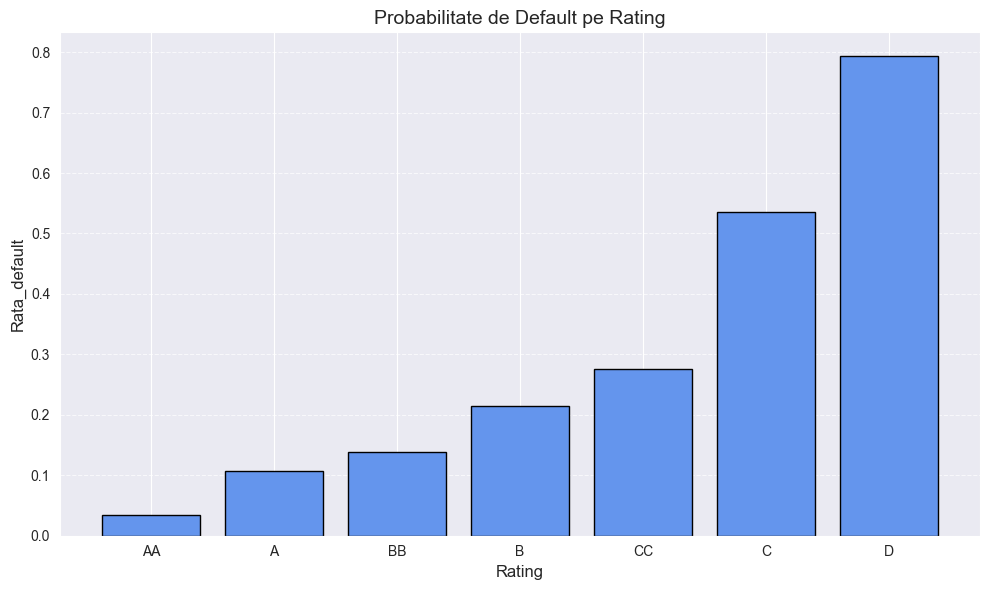

In [104]:
#rating_sorted = tabel_ratinguri.sort_values(by='Rata_default', ascending=True)
plt.figure(figsize=(10, 6))
tabel_ratinguri_sorted = tabel_ratinguri.set_index('rating').loc[rating[::-1]].reset_index()
plt.bar(tabel_ratinguri_sorted['rating'], tabel_ratinguri_sorted['Rata_default'], color='cornflowerblue', edgecolor='black')
plt.title("Probabilitate de Default pe Rating", fontsize=14)
plt.xlabel("Rating", fontsize=12)
plt.ylabel("Rata_default", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [105]:
#statistici pe ratinguti
stats_rating = df_score_var3.groupby('rating', observed=True)['scor_final'].agg(
    scor_minim='min',
    scor_maxim='max',
    scor_mediu='mean'
).reset_index()

print(stats_rating)

  rating  scor_minim  scor_maxim  scor_mediu
0      D  572.490978  609.203149  594.583738
1      C  610.802827  630.529280  621.486147
2     CC  630.772465  649.445067  641.358433
3      B  649.642164  665.156259  658.196381
4     BB  665.184686  677.466383  671.226095
5      A  677.739066  694.992993  686.180623
6     AA  696.175615  759.138463  721.634148


In [106]:
#tabel doar pt rating si pd
tabel_pd_real = df_score_var3.groupby('rating', observed=True)['clasa_reala'].mean().reset_index()
tabel_pd_real.columns = ['Rating', 'PD_real']

# Afișare tabel
print(tabel_pd_real)

  Rating   PD_real
0      D  0.793103
1      C  0.535714
2     CC  0.275862
3      B  0.214286
4     BB  0.137931
5      A  0.107143
6     AA  0.034483


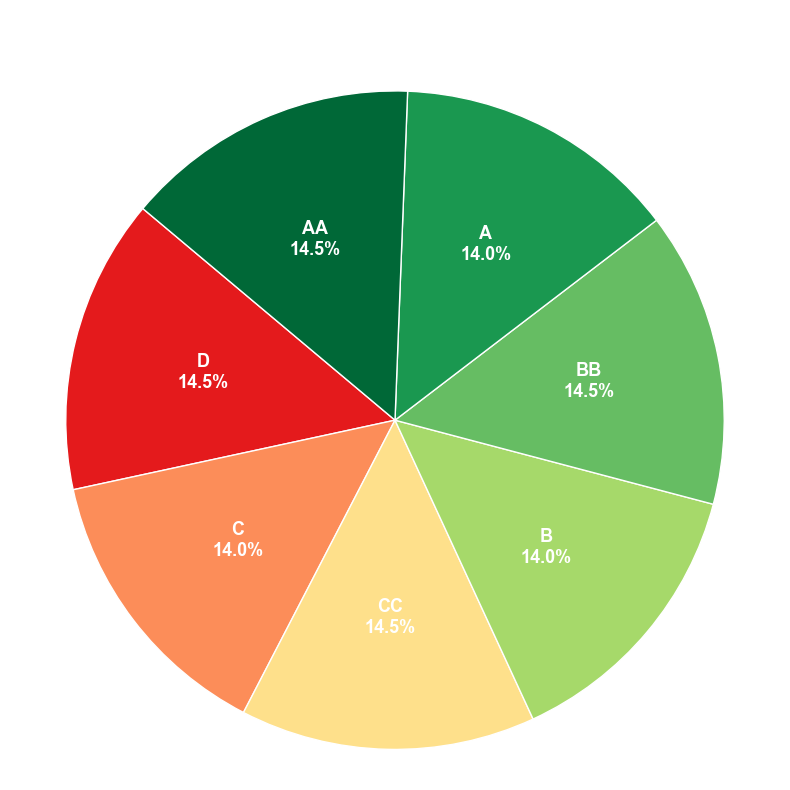

In [107]:
import matplotlib.pyplot as plt
import numpy as np

# Ratingurile și culorile asociate riscului
rating_order = ['D', 'C', 'CC', 'B', 'BB', 'A', 'AA']
frecv_rating = df_score_var3['rating'].value_counts().reindex(rating_order)
risk_colors = ['#e41a1c', '#fc8d59', '#fee08b', '#a6d96a', '#66bd63', '#1a9850', '#006837']

# Calculăm % manual
total = frecv_rating.sum()
procentaje = frecv_rating / total


plt.figure(figsize=(8, 8))
wedges, _ = plt.pie(
    frecv_rating.values,
    startangle=140,
    colors=risk_colors,
    wedgeprops=dict(edgecolor='white')
)

for i, wedge in enumerate(wedges):
    angle = (wedge.theta2 + wedge.theta1) / 2
    x = 0.6 * np.cos(np.deg2rad(angle))
    y = 0.6 * np.sin(np.deg2rad(angle))

    rating = rating_order[i]
    pct = f"{procentaje.iloc[i]*100:.1f}%"
    label = f"{rating}\n{pct}"

    plt.text(x, y, label, ha='center', va='center',
             fontsize=13, fontweight='bold', color='white')

# Titlu
plt.title('Distribuția clienților pe ratinguri\n(colorat în funcție de risc)', fontsize=16, fontweight='bold', color='white')
plt.axis('equal')
plt.tight_layout()
plt.show()


In [108]:
# Statistici descriptive scor_final
min_score = df_score_var3['scor_final'].min()
max_score = df_score_var3['scor_final'].max()
avg_score = df_score_var3['scor_final'].mean()

print(f"Scor minim: {min_score}")
print(f"Scor maxim: {max_score}")
print(f"Scor mediu: {avg_score}")

print(df_score_var3['scor_final'].describe())

Scor minim: 572.4909784680218
Scor maxim: 759.1384634235375
Scor mediu: 656.397191143562
count    200.000000
mean     656.397191
std       40.302306
min      572.490978
25%      627.754701
50%      659.934528
75%      680.291980
max      759.138463
Name: scor_final, dtype: float64
